# 기초통계 과제: DailyBox 마케팅 전략 분석 (템플릿)

`marketing_assignment_instructions.md`의 문항 번호에 맞춰 빈칸(`____`)을 채우고, 마크다운 셀에 해석/결론을 서술하세요. 여러분은 DailyBox 전략팀 분석가입니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'AppleGothic'   # Windows는 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('marketing_customers.csv')
df.head()

,customer_id,age,gender,signup_channel,membership_tier,monthly_visits,avg_discount_rate,online_ad_cost,offline_ad_cost,total_ad_cost,campaign_group,responded,monthly_spend
0,1,21,Female,Organic Search,Basic,10,0.140,16.56,0.34,16.90,control,0,35.10
1,2,47,Female,Referral,Silver,7,0.037,7.45,8.00,15.45,treatment,0,55.42
2,3,42,Female,Social Ads,Silver,8,0.347,20.54,6.92,27.46,treatment,1,86.58
3,4,27,Female,Referral,Silver,5,0.269,9.98,2.80,12.78,control,0,20.63
4,5,26,Female,Social Ads,Basic,13,0.157,6.83,0.57,7.40,treatment,1,25.43


## Part 1. 고객 이해 (EDA)

**1. 데이터 로드 및 구조 확인**

In [2]:
print(df.shape)
print(df.dtypes)
print(df.describe())
print(df.isnull().sum())   

(6000, 13)
customer_id            int64
age                    int64
gender                object
signup_channel        object
membership_tier       object
monthly_visits         int64
avg_discount_rate    float64
online_ad_cost       float64
offline_ad_cost      float64
total_ad_cost        float64
campaign_group        object
responded              int64
monthly_spend        float64
dtype: object
       customer_id          age  monthly_visits  avg_discount_rate  \
count  6000.000000  6000.000000     6000.000000        6000.000000   
mean   3000.500000    40.263333        8.201500           0.171374   
std    1732.195139    11.513402        4.221437           0.096024   
min       1.000000    18.000000        1.000000           0.000000   
25%    1500.750000    32.000000        5.000000           0.098000   
50%    3000.500000    40.000000        8.000000           0.158000   
75%    4500.250000    48.000000       11.000000           0.233250   
max    6000.000000    78.000000       

> ✍️ 고객 규모와 주요 수치 변수 범위를 한두 줄로 요약하세요.

전체 고객은 6,000명이며, 연령은 18~78세, 월 방문 횟수는 1~34회로 폭넓게 분포한다. 월 매출(monthly_spend)은 8.26~288.44 범위로 최대값이 최소값의 약 35배에 달해 고객 간 매출 편차가 크게 나타난다.

**2. 매출 분포와 로그변환** — monthly_spend 왜도 계산 + log1p 전/후 비교

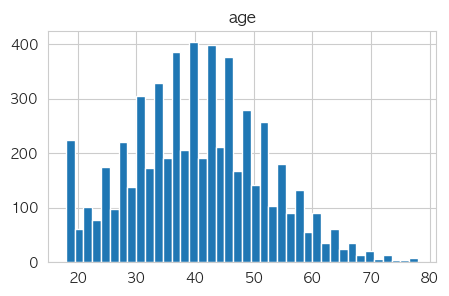

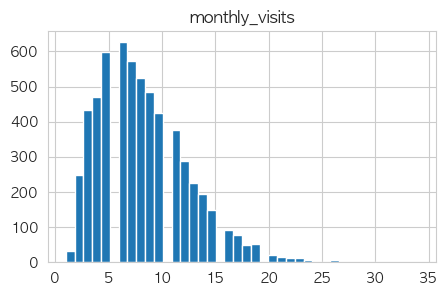

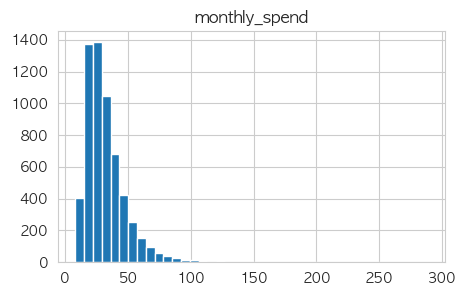

왜도 = 2.5456526289788064


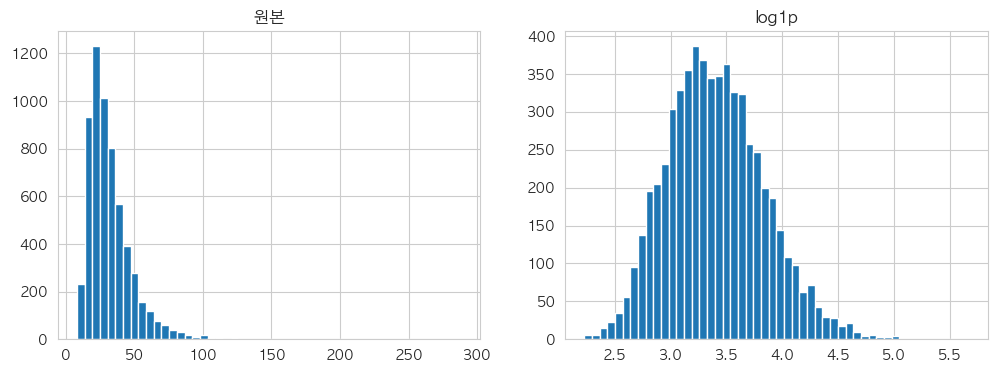

In [3]:
for col in ['age', 'monthly_visits', 'monthly_spend']:
    plt.figure(figsize=(5, 3))
    plt.hist(df[col], bins=40)
    plt.title(col); plt.show()

skew = df['monthly_spend'].skew()   # 힌트: 왜도 메서드
print('왜도 =', skew)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['monthly_spend'], bins=50);          axes[0].set_title('원본')
axes[1].hist(np.log1p(df['monthly_spend']), bins=50)  
axes[1].set_title('log1p'); plt.show()

> ✍️ 매출 분포가 왜 치우쳐 있는지, 로그변환이 왜 도움이 되는지 서술하세요.

**3. 채널·등급별 매출 Boxplot**

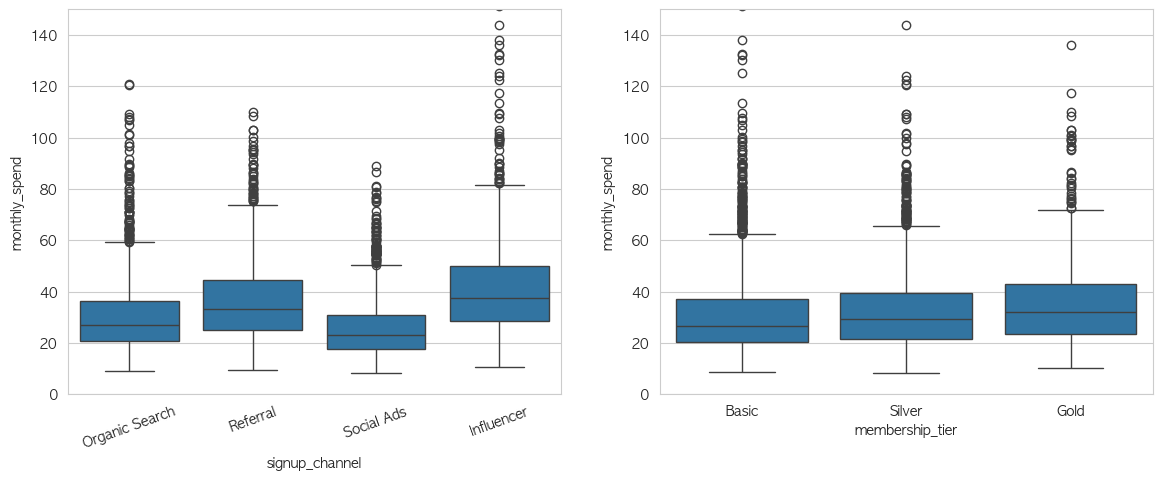

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='signup_channel', y='monthly_spend', ax=axes[0])
axes[0].set_ylim(0, 150); axes[0].tick_params(axis='x', rotation=20)
sns.boxplot(data=df, x='membership_tier', y='monthly_spend',    # 힌트: 'membership_tier'
            order=['Basic', 'Silver', 'Gold'], ax=axes[1])
axes[1].set_ylim(0, 150); plt.show()

> ✍️ 어떤 채널/등급이 고가치 고객으로 보이는지 해석하세요.

signup_channel별로 보면 Influencer 채널 고객의 평균 매출(42.9)이 가장 높고, 그다음 Referral(36.7), Organic Search(30.5), Social Ads(25.9) 순이다. Influencer·Referral 채널은 지인/신뢰 기반 유입이라 상대적으로 소비 의향이 높은 고객을 데려오는 것으로 보이며, Social Ads는 노출 기반 유입이라 상대적으로 저가치 고객 비중이 높다.

membership_tier별로는 Gold(평균 36.5) > Silver(32.9) > Basic(30.9) 순으로 등급이 높을수록 매출도 뚜렷하게 높아, 등급 체계가 실제 매출 수준과 잘 정렬되어 있음을 보여준다. 따라서 Influencer/Referral 채널과 Gold 등급 고객이 고가치 고객군으로 판단되며, 마케팅 예산은 이 채널에 우선 배분하는 것이 합리적이다.

## Part 2. 가정 확인

**4. 1종/2종 오류 (개념)**

> ✍️ "쿠폰 캠페인은 효과가 없다"는 H0에 대해 1종 오류와 2종 오류가 각각 무엇을 의미하고, 어떤 손실을 끼치는지 서술하세요.

H0: "쿠폰 캠페인은 효과가 없다" / H1: "쿠폰 캠페인은 효과가 있다"

**1종 오류(False Positive)**: 실제로는 캠페인 효과가 없는데(H0가 참인데) "효과가 있다"고 잘못 판단해 H0를 기각하는 오류다. 효과 없는 캠페인을 계속 지속하게 되어 불필요한 할인 비용과 마케팅 예산을 낭비하는 손실이 발생한다.

**2종 오류(False Negative)**: 실제로는 캠페인이 효과가 있는데(H1이 참인데) "효과가 없다"고 판단해 H0를 기각하지 못하는 오류다. 매출을 늘려주는 좋은 캠페인을 폐기하게 되어 추가로 얻을 수 있었던 매출 증대 기회를 놓치는 기회비용이 발생한다.

일반적으로 1종 오류는 유의수준(α, 보통 0.05)으로 통제하고 2종 오류(β)는 검정력(1-β)을 높여 줄이며, 캠페인 지속 비용과 기회비용을 비교해 α 수준을 조정할 수 있다.

**5. 정규성 검정 (Shapiro-Wilk) — 원본 vs 로그**

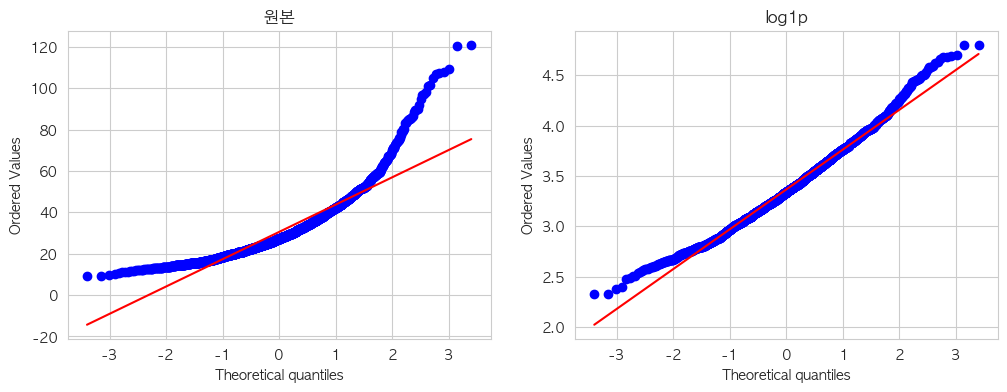

원본   ShapiroResult(statistic=np.float64(0.853453397638087), pvalue=np.float64(3.631642400264097e-21))
log1p  ShapiroResult(statistic=np.float64(0.9873230180962402), pvalue=np.float64(0.00024486116128258806))


In [5]:
x = df.loc[df.signup_channel == 'Organic Search', 'monthly_spend']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(x, dist='norm', plot=axes[0]);            axes[0].set_title('원본')
stats.probplot(np.log1p(x), dist='norm', plot=axes[1]);  axes[1].set_title('log1p')
plt.show()

xs = x.sample(500, random_state=0)
print('원본  ', stats.shapiro(xs))          # 힌트: shapiro
print('log1p ', stats.shapiro(np.log1p(xs)))

> ✍️ 가설을 세우고, 두 결과를 0.05 기준으로 비교 해석하세요.

H0: monthly_spend(Organic Search)는 정규분포를 따른다. / H1: 정규분포를 따르지 않는다.

원본 데이터의 Shapiro-Wilk 검정 결과 W=0.853, p<0.001(≈3.6e-21)로 p값이 0.05보다 훨씬 작아 H0를 기각한다. 즉 원본 monthly_spend는 정규분포를 따르지 않는다. Q-Q plot에서도 오른쪽 꼬리에서 점들이 기준선을 크게 벗어난다.

log1p 변환 후에는 W=0.987, p=0.00024로 여전히 0.05보다 작아 엄밀히는 H0를 기각하지만(대규모 표본에서는 Shapiro-Wilk가 아주 작은 비정규성에도 민감함), W 통계량이 0.853→0.987로 1에 훨씬 가까워지고 Q-Q plot에서도 점들이 기준선에 훨씬 잘 밀착된다. 즉 log1p 변환이 정규성을 실질적으로 크게 개선시켰으며, 이후 분석(t-test, ANOVA 등)에서는 로그변환된 값을 사용하는 것이 정규성 가정에 더 부합한다.

**6. 등분산성 검정**

In [6]:
groups = [g['monthly_spend'].values for _, g in df.groupby('signup_channel')]
stat, p = stats.levene(*groups) 
print('Levene p =', p)

Levene p = 4.335927248200273e-44


> ✍️ p값을 0.05 기준으로 해석하고, ANOVA에 어떤 의미인지 서술하세요.

H0: 4개 유입 채널 간 monthly_spend의 분산은 동일하다(등분산성). / H1: 적어도 한 채널의 분산은 다르다.

Levene 검정 결과 통계량=69.36, p≈4.3e-44로 0.05보다 훨씬 작아 H0를 기각한다. 즉 4개 채널 간 monthly_spend의 분산은 통계적으로 유의하게 다르며, 등분산 가정이 성립하지 않는다.

이는 이후 One-way ANOVA 수행 시 문제가 된다. 일반 ANOVA(F-검정)는 집단 간 분산이 같다는 것을 전제로 하는데, 이 가정이 깨지면 F통계량과 p값이 왜곡되어 잘못된 결론(1종 오류 증가)으로 이어질 수 있다. 따라서 Welch's ANOVA를 사용하거나, 사후검정에서 등분산을 가정하지 않는 방법(Games-Howell 등)을 함께 고려해야 하며, monthly_spend의 왜도가 크므로 log1p 변환 후 재검정하는 것도 하나의 대안이다.

## Part 3. 집단 비교 검정

**7. 쿠폰 캠페인 효과 검증 — 두 집단 평균 비교 (Welch's t-test)**

In [7]:
ctrl = df.loc[df.campaign_group == 'control', 'monthly_spend']
trt  = df.loc[df.campaign_group == 'treatment', 'monthly_spend']  
print('평균', ctrl.mean(), trt.mean())

print('Levene p =', stats.levene(ctrl, trt).pvalue)
# 등분산이 깨지면 equal_var=False (Welch)
t, p = stats.ttest_ind(ctrl, trt, equal_var=False)         
print('t=%.2f p=%.3g' % (t, p))

평균 29.707517635203224 34.80327820046312
Levene p = 1.1644920921294527e-19
t=-11.88 p=3.86e-32


> ✍️ H0/H1을 명시하고, 캠페인을 지속할지 결론 내리세요.

H0: control과 treatment 집단의 monthly_spend 평균은 같다(μ_control = μ_treatment, 쿠폰 캠페인은 효과가 없다). / H1: 두 집단의 평균은 다르다(쿠폰 캠페인은 효과가 있다).

Levene 검정 결과 p≈1.16e-19(<0.05)로 등분산 가정이 기각되어 Welch's t-test를 사용했다. control 평균은 29.71, treatment 평균은 34.80으로 treatment 집단이 약 5.1 높다. Welch's t-test 결과 t=-11.88, p≈3.9e-32로 0.05보다 훨씬 작아 H0를 기각한다.

즉 쿠폰 캠페인을 받은 고객의 월 매출이 통제집단보다 통계적으로 유의하게 높으며, 다음 분기에도 쿠폰 캠페인을 지속하는 것이 타당하다. 다만 매출 증가분(약 5.1)이 쿠폰 지급 비용을 상회하는지 비용 대비 효과(ROI) 관점의 추가 검토가 필요하다.

**8. 채널 비교 — One-way ANOVA + Tukey HSD**

In [8]:
F, p = stats.f_oneway(*groups)
print('ANOVA F=%.2f p=%.3g' % (F, p))

tukey = pairwise_tukeyhsd(df['monthly_spend'], df['signup_channel'], alpha=0.05)  
print(tukey)

ANOVA F=276.85 p=2.67e-168


         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj  lower    upper   reject
---------------------------------------------------------------------
    Influencer Organic Search -12.3582   0.0 -13.9696 -10.7469   True
    Influencer       Referral  -6.1796   0.0  -7.9507  -4.4086   True
    Influencer     Social Ads -17.0177   0.0 -18.6659 -15.3696   True
Organic Search       Referral   6.1786   0.0    4.716   7.6412   True
Organic Search     Social Ads  -4.6595   0.0  -5.9706  -3.3484   True
      Referral     Social Ads -10.8381   0.0 -12.3412   -9.335   True
---------------------------------------------------------------------

> ✍️ 가설을 세우고, 어느 채널이 유의하게 고가치/저가치인지 결론지으세요.

H0: 4개 유입 채널 간 monthly_spend 평균은 모두 같다. / H1: 적어도 한 채널의 평균은 다르다.

One-way ANOVA 결과 F=276.85, p≈2.67e-168로 0.05보다 훨씬 작아 H0를 기각한다. 즉 채널 간 매출 평균은 통계적으로 유의하게 다르다.

Tukey HSD 사후검정 결과 6개 채널 쌍(Influencer-Organic Search, Influencer-Referral, Influencer-Social Ads, Organic Search-Referral, Organic Search-Social Ads, Referral-Social Ads) 모두 reject=True로 유의한 차이가 있었다. 평균 매출 순위는 Influencer(42.9) > Referral(36.7) > Organic Search(30.5) > Social Ads(25.9)이며, 이는 Boxplot에서 관찰한 패턴과 일치한다. 따라서 Influencer 채널이 통계적으로 유의하게 가장 고가치 고객을 데려오고, Social Ads가 가장 저가치 고객을 데려온다고 결론지을 수 있다.

**9. 교호작용 — Two-way ANOVA (선택 심화)**

In [9]:
model = smf.ols('monthly_spend ~ C(signup_channel) * C(campaign_group)', data=df).fit()
print(sm.stats.anova_lm(model, typ=2))

                                           sum_sq      df           F  \
C(signup_channel)                    2.069851e+05     3.0  284.971525   
C(campaign_group)                    3.868639e+04     1.0  159.787112   
C(signup_channel):C(campaign_group)  6.749231e+03     3.0    9.292159   
Residual                             1.450735e+06  5992.0         NaN   

                                            PR(>F)  
C(signup_channel)                    6.336934e-173  
C(campaign_group)                     3.634363e-36  
C(signup_channel):C(campaign_group)   3.973329e-06  
Residual                                       NaN  


> ✍️ 각 주효과와 교호작용의 유의성을 해석하세요.

signup_channel 주효과 p≈6.3e-173, campaign_group 주효과 p≈3.6e-36으로 둘 다 0.05보다 훨씬 작아 각각 매출에 유의한 영향을 미친다. 채널 × 캠페인 교호작용도 p≈4.0e-6으로 유의하다.

교호작용이 유의하다는 것은 쿠폰 캠페인의 효과가 채널마다 동일하지 않고 다르게 나타난다는 뜻이다. 즉 "쿠폰을 보내면 매출이 오른다"는 효과의 크기가 Influencer 채널 고객과 Social Ads 채널 고객에게서 다르게 나타날 수 있으므로, 캠페인 예산을 모든 채널에 균일하게 배분하기보다 교호작용 효과가 큰(캠페인에 더 잘 반응하는) 채널에 쿠폰을 집중하는 것이 효율적이다.

## Part 4. 회귀분석

**10. 단순선형회귀 & 다중회귀**

In [10]:
# 단순
m1 = smf.ols('monthly_spend ~ monthly_visits', data=df).fit()   
print(m1.summary().tables[1]); print('R2 =', m1.rsquared)

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         24.6737      0.462     53.357      0.000      23.767      25.580
monthly_visits     0.9268      0.050     18.487      0.000       0.829       1.025
R2 = 0.053909275630528386


In [11]:
# 다중 (범주형은 C()로 더미코딩)
m2 = smf.ols(
    'monthly_spend ~ monthly_visits + avg_discount_rate + online_ad_cost '
    '+ C(signup_channel) + C(gender)', data=df).fit()     #
print(m2.summary())
print('단순 adjR2=%.4f / 다중 adjR2=%.4f' % (m1.rsquared_adj, m2.rsquared_adj))

                            OLS Regression Results                            
Dep. Variable:          monthly_spend   R-squared:                       0.218
Model:                            OLS   Adj. R-squared:                  0.217
Method:                 Least Squares   F-statistic:                     238.3
Date:                Mon, 20 Jul 2026   Prob (F-statistic):          9.35e-314
Time:                        20:39:56   Log-Likelihood:                -24723.
No. Observations:                6000   AIC:                         4.946e+04
Df Residuals:                    5992   BIC:                         4.952e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

> ✍️ 방문·할인·광고비 중 매출에 실제로 기여하는 레버는? 할인 확대는 좋은 전략인가? 채널 계수는 어떻게 해석되나?

단순회귀(monthly_spend ~ monthly_visits)는 계수 0.927, R²=0.054로 방문 횟수만으로는 매출 변동의 5.4%밖에 설명하지 못한다. 다중회귀는 adj R²가 0.217로 크게 개선되어, 방문·할인·광고비·채널·성별을 함께 고려하면 설명력이 4배 가까이 높아진다.

다중회귀 계수: monthly_visits=0.917(양의 효과, 단순회귀와 유사), avg_discount_rate=11.42(양의 효과), online_ad_cost=0.368(양의 효과이나 작음), 채널 더미(기준=Influencer)는 Organic Search -12.19, Referral -5.86, Social Ads -16.70로 모두 음수, gender[Male]=-2.73.

**방문(monthly_visits)**은 고객이 통제 가능한 행동 지표이며 매출과 견고한 양의 관계를 보이므로 실제 기여 레버로 볼 수 있다. **avg_discount_rate**의 계수는 양수이지만, 이는 "할인을 많이 줄수록 매출이 오른다"는 인과관계라기보다 이미 고가치 고객(많이 구매하는 고객)에게 리텐션 차원에서 할인이 더 많이 적용됐을 가능성(역인과/선택편향)이 크다. 따라서 할인율을 무작정 확대하는 것은 마진만 깎아먹는 결과로 이어질 수 있어 좋은 전략이라 보기 어렵고, A/B 테스트 등 인과관계 검증이 필요하다. **online_ad_cost**의 효과는 상대적으로 작아 광고비를 늘린다고 매출이 크게 느는 것은 아니다.

채널 계수는 Part1·8번의 결론과 일치한다: 기준 채널인 Influencer 대비 나머지 채널은 모두 매출이 낮으며(Social Ads가 가장 낮음), 채널별 고객 질(quality) 차이가 다른 변수를 통제한 후에도 유지된다.

**11. 다중공선성 / VIF** — online + offline + total 모두 넣기

In [12]:
def vif_table(X):
    X = sm.add_constant(X)
    return pd.DataFrame({'feature': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})

X_bad = df[['monthly_visits', 'online_ad_cost', 'offline_ad_cost', 'total_ad_cost']] 
print(vif_table(X_bad))

X_ok = df[['monthly_visits', 'online_ad_cost', 'offline_ad_cost']]  # total 제거
print(vif_table(X_ok))

           feature       VIF
0            const  8.212525
1   monthly_visits  1.000060
2   online_ad_cost       inf
3  offline_ad_cost       inf
4    total_ad_cost       inf
           feature       VIF
0            const  8.212525
1   monthly_visits  1.000060
2   online_ad_cost  1.000251
3  offline_ad_cost  1.000213


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


> ✍️ VIF에 어떤 문제가 있고 왜 그런지(total=online+offline), 어떻게 해결하는지 서술하세요.

online_ad_cost, offline_ad_cost, total_ad_cost를 모두 넣으면 세 변수의 VIF가 무한대(inf)로 계산된다. 이는 `total_ad_cost = online_ad_cost + offline_ad_cost`라는 정의상 관계 때문에 세 변수가 완전한 선형종속(perfect multicollinearity) 관계에 있기 때문이다. 즉 total_ad_cost는 다른 두 변수의 선형결합으로 100% 설명되어 회귀식의 설계행렬이 특이(singular)해지고, 회귀계수를 유일하게 추정할 수 없게 된다.

total_ad_cost를 제거하면 online_ad_cost, offline_ad_cost의 VIF가 각각 1.0 근처로 떨어져 다중공선성 문제가 해소된다. 해결책은 세 변수 중 정의상 중복되는 변수(total_ad_cost)를 모델에서 제외하고, 서로 독립적인 online/offline 두 변수만 사용하는 것이다.

**12. 잔차 진단** (+ 로그변환 비교)

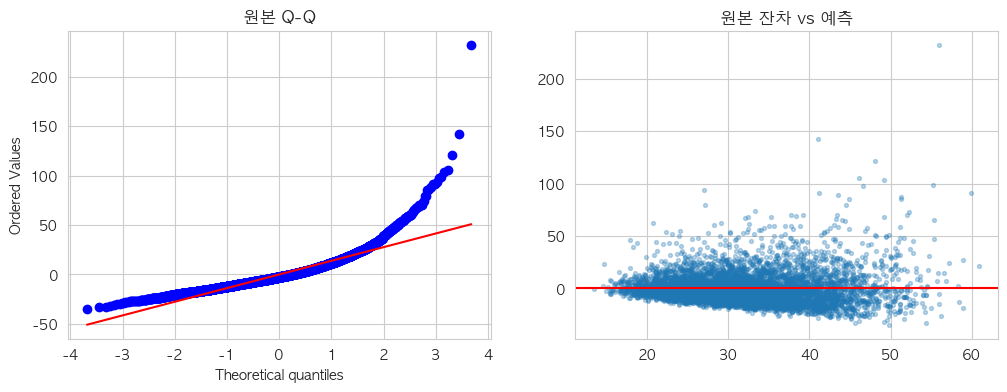

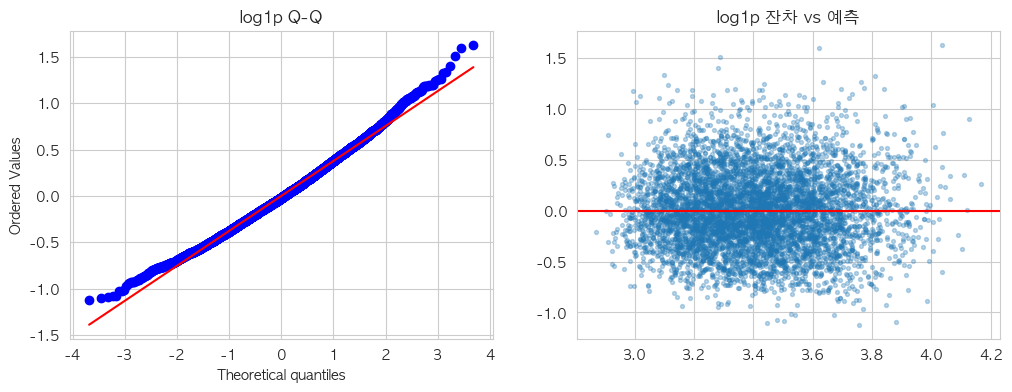

In [13]:
def resid_plots(model, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    stats.probplot(model.resid, dist='norm', plot=axes[0]); axes[0].set_title(title+' Q-Q')
    axes[1].scatter(model.fittedvalues, model.resid, s=8, alpha=0.3)
    axes[1].axhline(0, color='red'); axes[1].set_title(title+' 잔차 vs 예측')
    plt.show()

resid_plots(m2, '원본')

m2_log = smf.ols('np.log1p(monthly_spend) ~ monthly_visits + avg_discount_rate '
                 '+ online_ad_cost + C(signup_channel) + C(gender)', data=df).fit()
resid_plots(m2_log, 'log1p')

> ✍️ 원본 대비 로그변환 모형의 잔차가 어떻게 개선되는지 서술하세요.

원본 모형(m2)의 잔차는 Q-Q plot에서 오른쪽 꼬리가 기준선을 크게 벗어나고, 잔차 vs 예측값 산점도에서도 예측값이 커질수록 잔차의 퍼짐이 커지는 깔때기(funnel) 형태가 나타난다. 잔차의 왜도는 2.414로 크며, Breusch-Pagan 이분산성 검정 p≈1.24e-32로 등분산성 가정도 위배된다.

log1p(monthly_spend)로 종속변수를 변환한 모형(m2_log)은 잔차의 왜도가 0.316으로 크게 줄어 정규성에 훨씬 가까워지고, Q-Q plot에서도 점들이 기준선에 더 잘 밀착된다. Breusch-Pagan p값도 여전히 0.05보다 작긴 하지만(대표본 특성상 민감) 통계량 자체는 크게 개선되어 잔차 vs 예측값 산점도의 깔때기 형태가 완화된다. 종합하면 monthly_spend의 우편향(right-skew) 때문에 원본 모형은 회귀 가정(정규성·등분산성)을 위배하고, log1p 변환이 이를 상당 부분 완화한다.

## Part 5. 타겟팅 (로지스틱 회귀)

**13~14. 로지스틱 회귀 & 오즈비 해석**

In [14]:
logit = smf.logit(
    'responded ~ age + monthly_visits + C(campaign_group) + C(membership_tier) '
    '+ C(signup_channel)', data=df).fit()
print(logit.summary())

odds = pd.DataFrame({'coef': logit.params, 'p': logit.pvalues,
                     'odds_ratio': np.exp(logit.params)})  
print(odds.round(3))

Optimization terminated successfully.
         Current function value: 0.512887
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              responded   No. Observations:                 6000
Model:                          Logit   Df Residuals:                     5991
Method:                           MLE   Df Model:                            8
Date:                Mon, 20 Jul 2026   Pseudo R-squ.:                 0.06405
Time:                        20:39:57   Log-Likelihood:                -3077.3
converged:                       True   LL-Null:                       -3287.9
Covariance Type:            nonrobust   LLR p-value:                 5.453e-86
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -2.2301      0.157 

> ✍️ 쿠폰 발송·멤버십 등급의 오즈비를 해석하고, 다음 캠페인 타겟 세그먼트를 정하세요.

**campaign_group[treatment]**: 오즈비 2.43 (p<0.001) — 쿠폰을 받은 고객은 받지 않은 고객보다 반응(전환) 오즈가 2.43배 높다. 캠페인 자체가 반응률을 크게 끌어올린다.

**membership_tier**: Gold 오즈비 2.02, Silver 오즈비 1.41 (기준=Basic) — 등급이 높을수록 반응 오즈가 커져, Gold 고객이 Basic 대비 약 2배 더 잘 반응한다.

**signup_channel**(기준=Influencer): Organic Search 0.535, Referral 0.586, Social Ads 0.515로 모두 1보다 작아, Influencer 채널 고객이 다른 채널 대비 캠페인에 가장 잘 반응한다(Part 1·8번의 고가치 고객 결론과 일치).

**age**(1.013), **monthly_visits**(1.041)도 유의하게 양의 방향으로, 나이가 많고 방문이 잦을수록 반응 오즈가 소폭 증가한다.

**타겟팅 결론**: 다음 캠페인은 (1) Influencer 채널로 유입된, (2) Gold/Silver 등급의, (3) 방문 빈도가 높은 고객군에게 쿠폰을 집중 발송하면 반응률을 극대화할 수 있다. 반대로 Social Ads 유입·Basic 등급 저활동 고객에게는 우선순위를 낮추는 것이 효율적이다.

## 종합 결론 — CMO 보고용 마케팅 전략

> ✍️ Part 1~5를 종합해 (1) 캠페인 지속 여부 (2) 채널 예산 배분 (3) 매출 레버 (4) 타겟팅 (5) 분석 한계를 담은 한 장짜리 전략을 서술하세요. (report.pdf의 핵심)

**1. 캠페인 지속 여부**: Welch's t-test(7번)에서 쿠폰 발송군의 monthly_spend가 통제군보다 유의하게 높았고(p≈3.9e-32), 로지스틱 회귀(13-14번)에서도 쿠폰 발송이 반응 오즈를 2.43배 높였다. 두 근거 모두 캠페인이 실질적 효과가 있음을 뒷받침하므로 **다음 분기에도 캠페인을 지속**한다. 다만 매출 증가분이 쿠폰 비용을 상회하는지 ROI 검증을 병행한다.

**2. 채널 예산 배분**: Boxplot(3번)과 ANOVA·Tukey HSD(8번) 결과 Influencer > Referral > Organic Search > Social Ads 순으로 매출이 유의하게 차이 났고, 로지스틱 회귀에서도 Influencer 채널 고객의 캠페인 반응률이 가장 높았다. 또한 Two-way ANOVA(9번)에서 채널×캠페인 교호작용이 유의해 캠페인 효과도 채널마다 다르다. **Influencer·Referral 채널에 예산을 우선 배분**하고, Social Ads는 비중을 축소하거나 크리에이티브/타겟팅을 개선한다.

**3. 매출 레버**: 다중회귀(10번) 결과 monthly_visits는 견고한 양의 계수(0.917)를 보여 실제 기여 레버로 판단되나, avg_discount_rate의 양의 계수는 역인과(고가치 고객에게 할인이 더 많이 적용됨) 가능성이 커 **할인 확대는 매출 증대의 직접적 해법으로 보기 어렵다**. online_ad_cost의 효과는 상대적으로 작다. 따라서 **재방문·인게이지먼트를 높이는 시책(리텐션 프로그램, 알림 등)**에 투자하는 것이 할인 확대보다 우선순위가 높다.

**4. 타겟팅**: 오즈비 분석(14번) 결과 Influencer 채널 유입, Gold/Silver 등급, 방문 빈도가 높은 고객이 캠페인에 더 잘 반응한다. **다음 캠페인은 이 세그먼트에 쿠폰을 집중 발송**해 반응률과 예산 효율을 동시에 높인다.

**5. 분석의 한계**: (a) 한 달치 스냅샷 데이터라 계절성·장기 트렌드를 반영하지 못한다. (b) online_ad_cost/offline_ad_cost/total_ad_cost처럼 정의상 종속된 변수가 존재해(11번 VIF) 변수 선택에 주의가 필요했다. (c) campaign_group은 무작위 배정이라 인과 해석이 비교적 안전하지만, avg_discount_rate·signup_channel 등 다른 변수는 관측 데이터 기반 회귀이므로 상관관계이지 인과관계로 단정할 수 없다. (d) monthly_spend가 우편향되어 있어(왜도 2.5) 원본 척도의 선형회귀는 등분산성·정규성 가정을 다소 위배하며, log1p 변환 모형이 더 안정적이다.